In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

### Required Libraries

- **Pandas** is used to load and handle the CSV datasets.
- **NumPy** is used for numerical operations, matrix calculations, and implementing Ridge regression.
- **Matplotlib** is used to plot the CV MSE and CV R² against polynomial degree.
- **KFold** is used to perform 5-fold cross-validation for model evaluation.

In [3]:
# Load data
train_df = pd.read_csv("BT2024085_train_var2.csv")
test_df = pd.read_csv("BT2024085_test_var2.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training shape: (1000, 4)
Test shape: (1000, 3)


In [4]:
# Separate features and target
features = ["x1", "x2", "x3"]
X = train_df[features].values
y = train_df["y"].values
X_test = test_df[features].values

In [6]:
# Generate exponent combinations
def generate_exponents(degree, n_features=3):
    exponents = []
    for i in range(degree + 1):
        for j in range(degree - i + 1):
            k = degree - i - j
            exponents.append((i, j, k))
    return exponents

### Polynomial Feature Generation

Polynomial features allow the model to represent nonlinear relationships
between the input variables and the target. The exponent combinations
are generated manually so that all required polynomial and interaction
terms up to the selected degree can be constructed.

In [ ]:
# Create polynomial features manually
def make_polynomial_features(X, degree):
    polynomial_terms = []
    for current_degree in range(1, degree + 1):
        exponents = generate_exponents(
            current_degree,
            X.shape[1]
        )
        for powers in exponents:
            term = np.ones(X.shape[0])
            for feature_index in range(X.shape[1]):

                term = term * (
                    X[:, feature_index] ** powers[feature_index]
                )

            polynomial_terms.append(term)

    return np.column_stack(polynomial_terms)

### Ridge Regression

Ridge regression adds L2 regularization to the least-squares objective.
The regularization parameter α controls the strength of the penalty and
helps control large coefficients when many polynomial terms are present.
The intercept is not penalized.

In [7]:
# Calculate Ridge weights
def calculate_ridge_weights(X, y, alpha):
    X_bias = np.column_stack((np.ones(X.shape[0]), X))
    n_features = X_bias.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0
    weights = np.linalg.solve(X_bias.T @ X_bias + alpha * I,X_bias.T @ y)
    return weights

In [8]:
# Make predictions
def predict(X, weights):
    X_bias = np.column_stack((np.ones(X.shape[0]), X))
    return X_bias @ weights

### Evaluation Metrics for taking best polynomial

**MSE** measures the average squared prediction error, so a lower value
indicates better performance. **R²** measures the proportion of variance
in the target explained by the model, so a higher value generally
indicates better performance.

In [9]:
# Calculate MSE
def calculate_mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

# Calculate R2
def calculate_r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

### Model Selection using 5-Fold Cross-Validation

5-fold cross-validation is used to evaluate how well different polynomial
degrees generalize to unseen data. For each degree, multiple Ridge α
values are tested, and the α giving the lowest mean validation MSE is
selected. The degree with the lowest resulting CV MSE is then selected
as the final model

In [10]:
# Setup 5-fold cross validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
# Alpha values to test
alphas = [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,10]
# Test degrees from 1 to 20
results = []

### Cross-Validation Results

The CV MSE and CV R² are plotted against polynomial degree to visualize
how model performance changes as the polynomial complexity increases.

In [12]:
for degree in range(1, 21):
    best_degree_mse = float("inf")
    best_degree_r2 = None
    best_degree_alpha = None
    # Try different alpha values
    for alpha in alphas:
        mse_values = []
        r2_values = []
        # Perform 5-fold cross validation
        for train_index, val_index in kf.split(X):
            # Split training and validation data
            X_train = X[train_index]
            y_train = y[train_index]
            X_val = X[val_index]
            y_val = y[val_index]
            # Create polynomial features
            X_train_poly = make_polynomial_features(X_train,degree)
            X_val_poly = make_polynomial_features(X_val,degree)
            # Calculate Ridge weights
            weights = calculate_ridge_weights(X_train_poly,y_train,alpha)
            # Predict validation data
            y_val_pred = predict(X_val_poly,weights)
            # Calculate validation metrics
            fold_mse = calculate_mse(y_val,y_val_pred)
            fold_r2 = calculate_r2(y_val,y_val_pred)
            mse_values.append(fold_mse)
            r2_values.append(fold_r2)

        # Average CV metrics
        mean_mse = np.mean(mse_values)
        mean_r2 = np.mean(r2_values)
        # Keep best alpha for this degree
        if mean_mse < best_degree_mse:
            best_degree_mse = mean_mse
            best_degree_r2 = mean_r2
            best_degree_alpha = alpha
    # Store best result for this degree
    results.append((degree,best_degree_mse,best_degree_r2,best_degree_alpha))
    # Print CV results
    print(f"Degree {degree:2d} | "f"CV MSE: {best_degree_mse:.4f} "f"(R2: {best_degree_r2:.4f}) | "f"Alpha: {best_degree_alpha:.0e}")

Degree  1 | CV MSE: 28.8029 (R2: 0.2263) | Alpha: 1e+00
Degree  2 | CV MSE: 18.2565 (R2: 0.5089) | Alpha: 1e+00
Degree  3 | CV MSE: 9.8073 (R2: 0.7375) | Alpha: 1e-01
Degree  4 | CV MSE: 3.2629 (R2: 0.9126) | Alpha: 1e-01
Degree  5 | CV MSE: 1.3842 (R2: 0.9629) | Alpha: 1e-02
Degree  6 | CV MSE: 0.4985 (R2: 0.9865) | Alpha: 1e-08
Degree  7 | CV MSE: 0.3370 (R2: 0.9909) | Alpha: 1e-02
Degree  8 | CV MSE: 0.2597 (R2: 0.9930) | Alpha: 1e-02
Degree  9 | CV MSE: 0.2600 (R2: 0.9929) | Alpha: 1e-02
Degree 10 | CV MSE: 0.2439 (R2: 0.9934) | Alpha: 1e-01
Degree 11 | CV MSE: 0.2430 (R2: 0.9934) | Alpha: 1e-01
Degree 12 | CV MSE: 0.2376 (R2: 0.9935) | Alpha: 1e-01
Degree 13 | CV MSE: 0.2386 (R2: 0.9935) | Alpha: 1e-01
Degree 14 | CV MSE: 0.2398 (R2: 0.9935) | Alpha: 1e-01
Degree 15 | CV MSE: 0.2420 (R2: 0.9934) | Alpha: 1e-01
Degree 16 | CV MSE: 0.2464 (R2: 0.9933) | Alpha: 1e-01
Degree 17 | CV MSE: 0.2477 (R2: 0.9932) | Alpha: 1e+00
Degree 18 | CV MSE: 0.2481 (R2: 0.9932) | Alpha: 1e+00
Degree 1

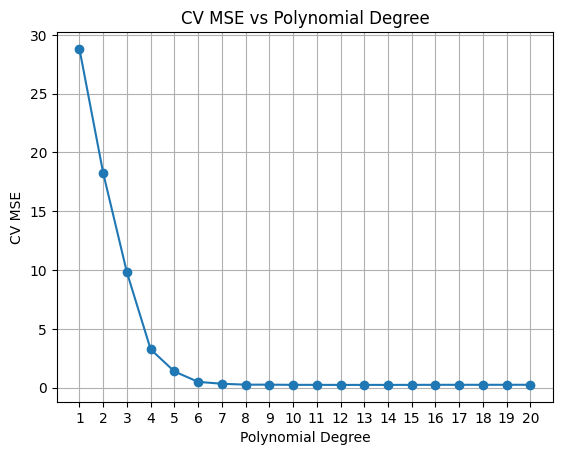

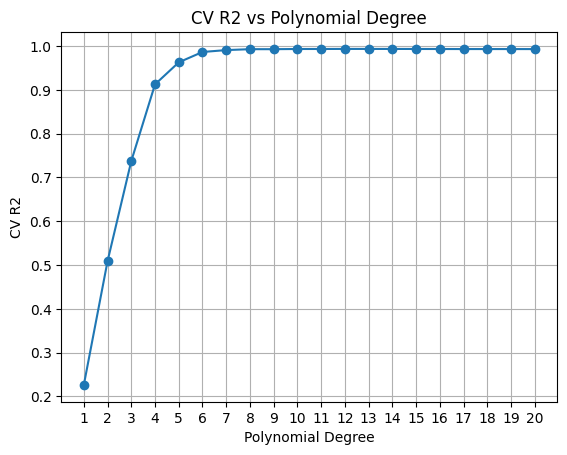

In [13]:
# Plot CV MSE and CV R2
degrees = [r[0] for r in results]
cv_mse = [r[1] for r in results]
cv_r2 = [r[2] for r in results]


# CV MSE graph
plt.figure()
plt.plot(
    degrees,
    cv_mse,
    marker="o"
)
plt.xlabel("Polynomial Degree")
plt.ylabel("CV MSE")
plt.title("CV MSE vs Polynomial Degree")
plt.xticks(degrees)
plt.grid(True)
plt.show()


# CV R2 graph
plt.figure()
plt.plot(
    degrees,
    cv_r2,
    marker="o"
)
plt.xlabel("Polynomial Degree")
plt.ylabel("CV R2")
plt.title("CV R2 vs Polynomial Degree")
plt.xticks(degrees)
plt.grid(True)
plt.show()

In [14]:
# Select best degree and alpha
best_degree, best_mse, best_r2, best_alpha = min(results,key=lambda x: x[1])
print("\nBest Degree:", best_degree)
print("Best CV MSE:", best_mse)
print("Best CV R2:", best_r2)
print("Best Alpha:", best_alpha)

# Train final model using all training data
X_poly = make_polynomial_features(X,best_degree)
X_test_poly = make_polynomial_features(X_test,best_degree)

# Calculate final Ridge weights
weights = calculate_ridge_weights(X_poly,y,best_alpha)

# Calculate final training performance
y_train_pred = predict(X_poly,weights)
train_mse = calculate_mse(y,y_train_pred)

train_r2 = calculate_r2(y,y_train_pred)

print("\nFinal Training MSE:", train_mse)
print("Final Training R2:", train_r2)


Best Degree: 12
Best CV MSE: 0.23756302372278776
Best CV R2: 0.9935405570461059
Best Alpha: 0.1

Final Training MSE: 0.1563485678672706
Final Training R2: 0.9958331392122189


In [15]:
# Predict test data
y_test_pred = predict(X_test_poly,weights)
# Save predictions
submission = pd.DataFrame({"y": y_test_pred})
submission.to_csv("BT2024085_predictions_var2.csv",index=False)
print("\nPredictions saved to:")
print("BT2024085_predictions_var2.csv")


Predictions saved to:
BT2024085_predictions_var2.csv
